## Tissue masking on pixel-skipping IMC data

In [1]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from masking import TissueMasker
import os

In [2]:
root_path = "./data/pixel_skip"
file_name = "pixel_skip.tiff"

In [3]:
img = tifffile.imread(os.path.join(root_path, "img", file_name))
print("Image shape:", img.shape)

Image shape: (40, 429, 593)


After loading the pixel skip image, we will use TissueMasker to create a tissue mask.

In [4]:
tissue_masker = TissueMasker(nbins = 256,
                            smooth_sigma_hist = 1.0,
                            median_filter_size = 7,
                            n_peaks = 1,
                            gaussian_smoothing = 3.0,)
image_mask = tissue_masker.process_image(img)

Lets also quickly verify that everything worked as intended by visualizing both, the image and the mask next to each other. We will arcsinh transform the image to compress the dynamic range and simply visualize the first 3 channels.

In [5]:
display_img = np.arcsinh(img / 5.0)[:3].transpose(1,2,0)
display_img.shape

(429, 593, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4.0238843].


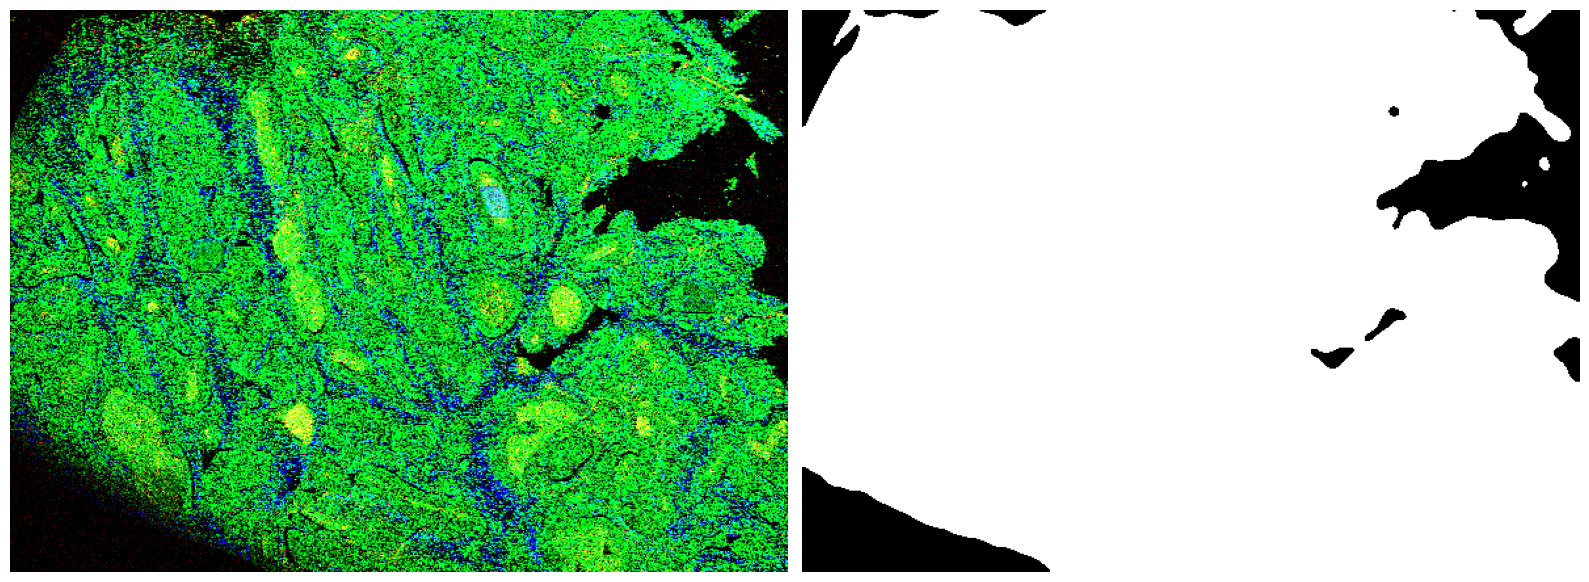

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 10))
im1 = axs[0].imshow(display_img)
axs[0].axis("off")
im2 = axs[1].imshow(image_mask.squeeze(), cmap='grey')
axs[1].axis("off")
plt.tight_layout()
plt.show()

Finally, we will save the mask so we can later investigate it with napari.

In [7]:
if not os.path.exists(os.path.join(root_path, "masks")):
    os.makedirs(os.path.join(root_path, "masks"))
plt.imsave(os.path.join(root_path, "masks", file_name.split('.')[0] + "_mask.tiff"), image_mask.squeeze())